<a href="https://colab.research.google.com/github/jaimeisaac2020/Python-analsisis-basicos/blob/mi-github/pronosticos_tesis_amazon_chronos_libreria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Paso 1: Instalar las librerías necesarias
# Descomenta las siguientes líneas si no las has instalado
!pip install torch
!pip install chronos-forecasting
!pip install accelerate

In [3]:
import pandas as pd
import torch
from chronos import BaseChronosPipeline
import matplotlib.pyplot as plt
import warnings

# Ignorar advertencias para una salida más limpia
warnings.filterwarnings("ignore")

In [6]:
try:
    # --- 1. Cargar y Preparar los Datos ---
    print("Cargando el dataset 'dataset_completo_google_amazon.csv'...")
    df = pd.read_csv('dataset_completo_google_amazon.csv')

    # Convertir la columna 'Date' a formato datetime y establecerla como índice
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    # Seleccionar la serie de tiempo del precio de cierre de Google
    google_series = df['GOOGL_Close']

    # Asegurarnos de que la serie tenga una frecuencia de días hábiles ('B')
    # y rellenar cualquier posible hueco (aunque tu dataset parece no tenerlos)
    google_series = google_series.asfreq('B').ffill()

    print(f"Datos históricos cargados. La serie contiene {len(google_series)} puntos de datos de días hábiles.")
    print(f"El rango de fechas va de {google_series.index.min().date()} a {google_series.index.max().date()}.")
except FileNotFoundError:
    print("Error: El archivo 'dataset_completo_google_amazon.csv' no fue encontrado.")
except Exception as e:
    print(f"Ocurrió un error al cargar o preparar los datos: {e}")

Cargando el dataset 'dataset_completo_google_amazon.csv'...
Datos históricos cargados. La serie contiene 1041 puntos de datos de días hábiles.
El rango de fechas va de 2021-01-04 a 2024-12-30.


In [7]:
google_series.head()

,GOOGL_Close
Date,
2021-01-04,85.895844
2021-01-05,86.588524
2021-01-06,85.734100
2021-01-07,88.294868
2021-01-08,89.463783


In [9]:
# --- 2. Configurar el Pipeline de Chronos ---
print("\nInicializando el pipeline de Amazon Chronos...")
print("Este paso puede tardar un poco mientras se descarga el modelo.")

# Nota: Si no tienes una GPU disponible, cambia "cuda" a "cpu".
# El proceso será más lento en CPU.
device = "cuda" if torch.cuda.is_available() else "cpu"

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map=device,
    torch_dtype=torch.bfloat16,
)
print(f"Pipeline cargado y funcionando en '{device}'.")


Inicializando el pipeline de Amazon Chronos...
Este paso puede tardar un poco mientras se descarga el modelo.


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/185M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/142 [00:00<?, ?B/s]

Pipeline cargado y funcionando en 'cpu'.


In [11]:
# --- 3. Generar Pronóstico para 2025 ---
# El contexto es toda la serie histórica disponible (2021-2024)
contexto = torch.tensor(google_series.values, dtype=torch.bfloat16)

# Calcular cuántos días hábiles hay en 2025 para la predicción
dias_habiles_2025 = pd.bdate_range(start='2025-01-01', end='2025-12-31')
prediction_length = len(dias_habiles_2025)

print(f"\nRealizando pronóstico para los {prediction_length} días hábiles de 2025...")


Realizando pronóstico para los 261 días hábiles de 2025...


In [13]:
# Predecir los cuantiles para obtener la mediana y el intervalo de confianza
quantiles_tensor, _ = pipeline.predict_quantiles(
    context=contexto.to(device),
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9],  # Cuantiles 10%, 50% (mediana) y 90%
)

# Mover los resultados de vuelta a la CPU y a formato NumPy para su manipulación
quantiles = quantiles_tensor.cpu().numpy()

print("Pronóstico completado.")

Pronóstico completado.


In [14]:
    # --- 4. Procesar y Mostrar los Resultados ---
    # Extraer los cuantiles para el gráfico
    low, median, high = quantiles[0, :, 0], quantiles[0, :, 1], quantiles[0, :, 2]

    # Crear un DataFrame con el pronóstico para una visualización clara
    forecast_df = pd.DataFrame(
        data={'Baja (10%)': low, 'Mediana (50%)': median, 'Alta (90%)': high},
        index=dias_habiles_2025
    )

    print("\n--- Primeros 10 días del pronóstico para GOOGL en 2025 ---")
    print(forecast_df.head(10).to_string(float_format="%.2f"))
    print("\n--- Últimos 10 días del pronóstico para GOOGL en 2025 ---")
    print(forecast_df.tail(10).to_string(float_format="%.2f"))


--- Primeros 10 días del pronóstico para GOOGL en 2025 ---
            Baja (10%)  Mediana (50%)  Alta (90%)
2025-01-01      189.85         191.51      194.10
2025-01-02      189.85         192.03      197.22
2025-01-03      188.81         191.51      195.25
2025-01-06      189.85         193.07      197.32
2025-01-07      189.74         193.07      199.40
2025-01-08      190.99         194.62      202.72
2025-01-09      188.91         195.14      203.45
2025-01-10      190.78         196.18      201.58
2025-01-13      192.55         195.14      203.45
2025-01-14      189.95         195.14      202.51

--- Últimos 10 días del pronóstico para GOOGL en 2025 ---
            Baja (10%)  Mediana (50%)  Alta (90%)
2025-12-18      181.50         195.83      209.01
2025-12-19      181.37         197.11      209.01
2025-12-22      181.24         195.83      207.86
2025-12-23      182.65         195.19      207.86
2025-12-24      180.34         197.11      207.86
2025-12-25      193.91         

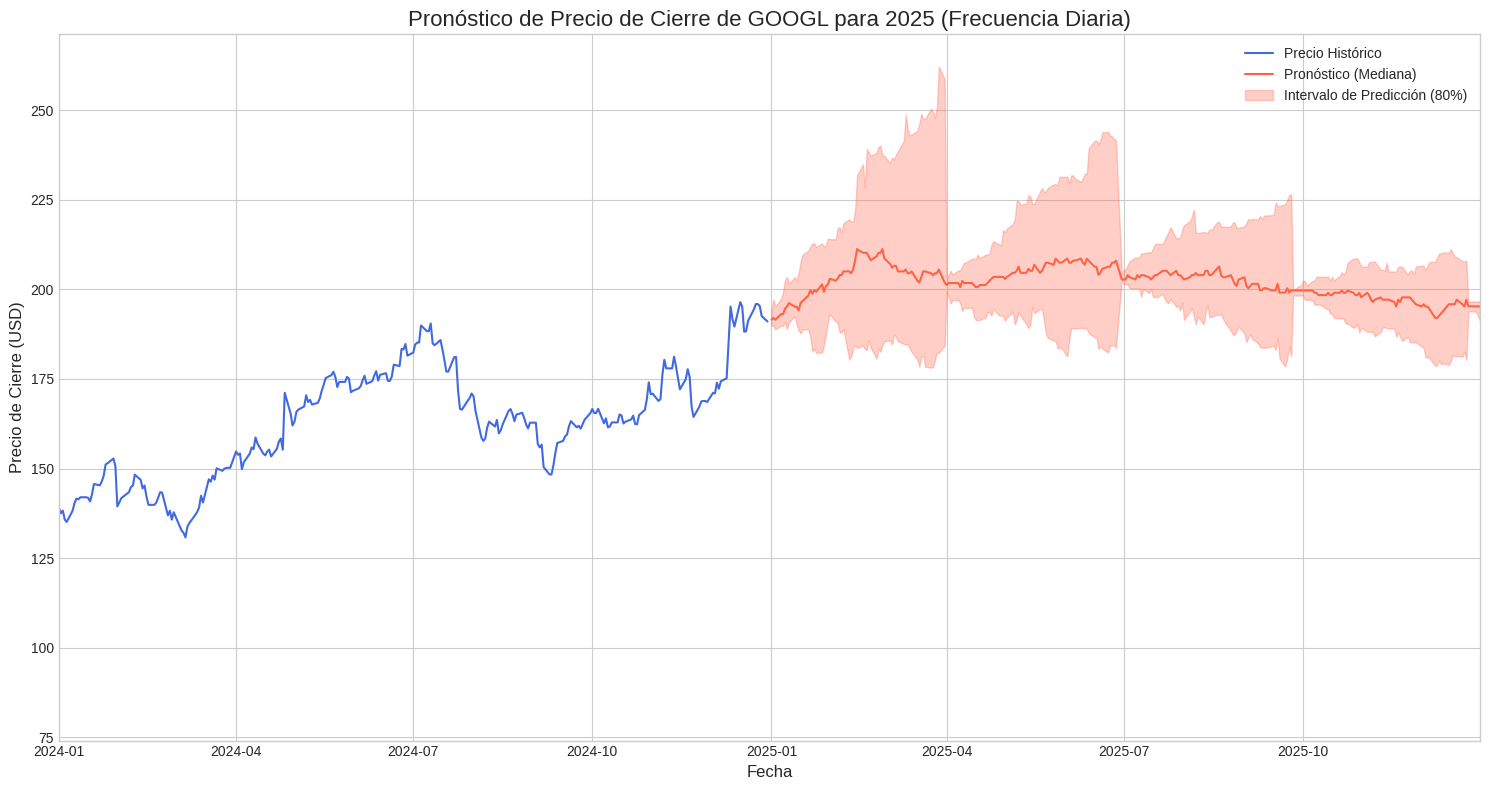

In [17]:
# --- 5. Visualizar los Resultados ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 8))

# Graficar la serie histórica
ax.plot(google_series.index, google_series.values, color="royalblue", label="Precio Histórico")

# Graficar la predicción de la mediana
ax.plot(forecast_df.index, forecast_df['Mediana (50%)'], color="tomato", label="Pronóstico (Mediana)")

# Rellenar el área del intervalo de confianza
ax.fill_between(forecast_df.index,
                forecast_df['Baja (10%)'],
                forecast_df['Alta (90%)'],
                color="tomato", alpha=0.3, label="Intervalo de Predicción (80%)")

ax.set_title('Pronóstico de Precio de Cierre de GOOGL para 2025 (Frecuencia Diaria)', fontsize=16)
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Precio de Cierre (USD)", fontsize=12)
ax.legend()
ax.grid(True)

# Ajustar el límite del eje X para enfocar en el final del histórico y el pronóstico
ax.set_xlim([pd.to_datetime('2024-01-01'), pd.to_datetime('2025-12-31')])

plt.tight_layout()
plt.show()

In [19]:
# Calcular el Error Cuadrático Medio (MSE)
# This code requires 'validation_data' and 'median_forecast' which are not defined in the current notebook.
# To calculate MSE, you would need a dataset with actual values for the forecast period to compare against the predicted values.
# mse = mean_squared_error(validation_data.values, median_forecast)

# print("\n--- Resultados de la Validación ---")
# print(f"Error Cuadrático Medio (MSE) del pronóstico: {mse:.4f}")

Cargando el dataset 'dataset_completo_google_amazon.csv'...
Datos históricos cargados. La serie va de 2021-01-04 a 2024-12-30.

Inicializando el pipeline de Amazon Chronos...


Pipeline cargado y funcionando en 'cpu'.

--- Iniciando la fase de validación para calcular el error ---
Usando datos hasta 2024-09-27 para entrenar.
Validando el pronóstico para el período de 2024-09-30 a 2024-12-30.



--- Resultados de la Validación ---
Error Cuadrático Medio (MSE) del pronóstico: 127.1759

--- Iniciando el pronóstico final para 2025 (usando todos los datos históricos) ---
Realizando pronóstico para los 261 días hábiles de 2025...
Pronóstico completado.

--- Primeros 10 días del pronóstico para GOOGL en 2025 ---
            Baja (10%)  Mediana (50%)  Alta (90%)
2025-01-01      188.91         192.03      195.25
2025-01-02      187.77         191.51      195.25
2025-01-03      187.77         191.51      196.18
2025-01-06      187.88         192.03      197.22
2025-01-07      185.59         192.55      199.29
2025-01-08      186.32         194.10      199.29
2025-01-09      184.14         195.66      200.44
2025-01-10      177.50         196.18      203.45
2025-01-13      180.51         196.18      199.50
2025-01-14      181.44         195.14      201.37


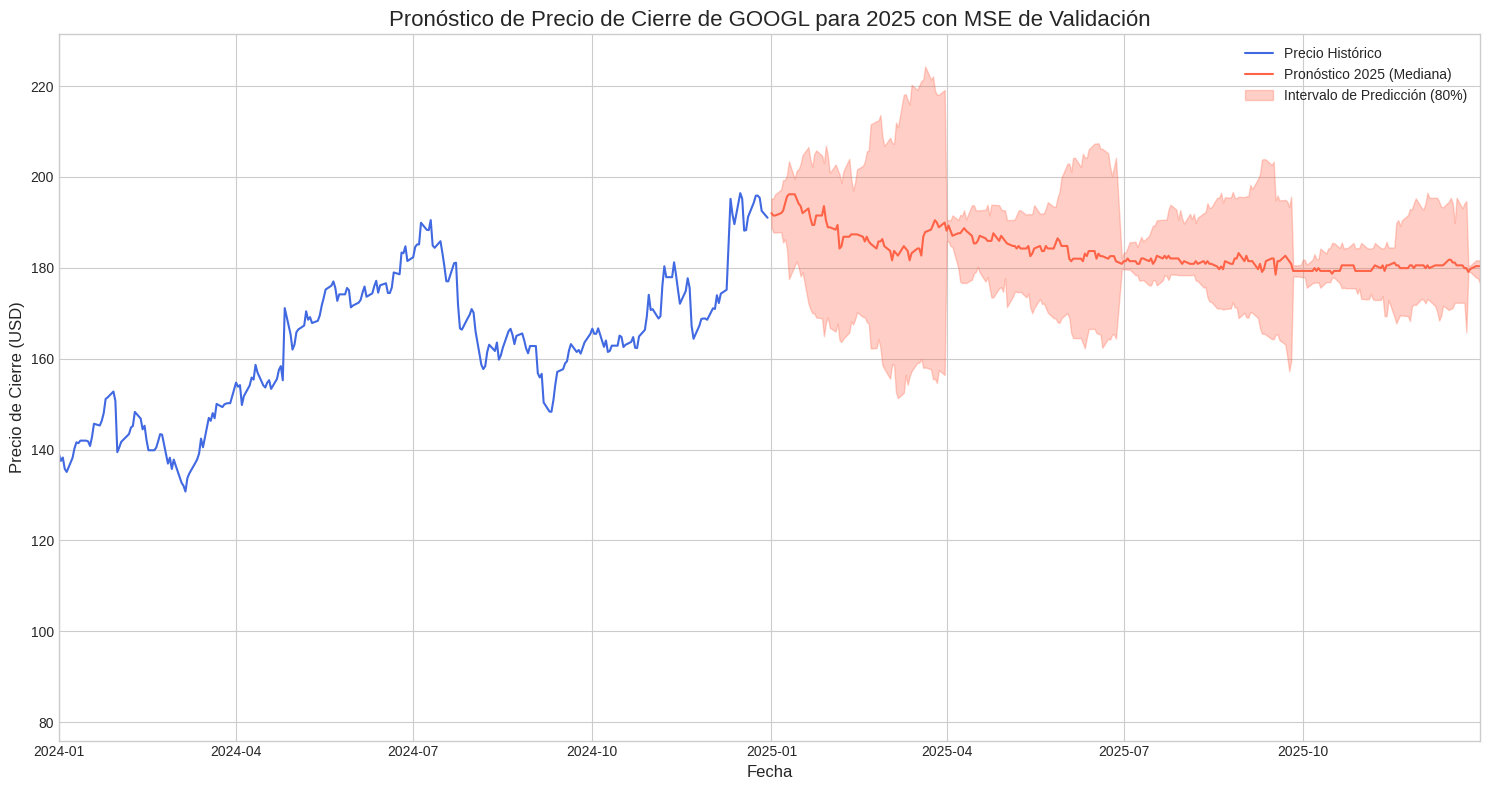

In [20]:
# Paso 1: Instalar las librerías necesarias
# Si no las has instalado, descomenta y ejecuta estas líneas en tu entorno
# !pip install torch
# !pip install chronos-forecasting
# !pip install accelerate
# !pip install scikit-learn

import pandas as pd
import torch
from chronos import BaseChronosPipeline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
import warnings

# --- Configuración ---
warnings.filterwarnings("ignore")

try:
    # --- 1. Cargar y Preparar los Datos ---
    print("Cargando el dataset 'dataset_completo_google_amazon.csv'...")
    df = pd.read_csv('dataset_completo_google_amazon.csv')

    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    google_series = df['GOOGL_Close'].asfreq('B').ffill()

    print(f"Datos históricos cargados. La serie va de {google_series.index.min().date()} a {google_series.index.max().date()}.")

    # --- 2. Configurar el Pipeline de Chronos ---
    print("\nInicializando el pipeline de Amazon Chronos...")
    device = "cuda" if torch.cuda.is_available() else "cpu"

    pipeline = BaseChronosPipeline.from_pretrained(
        "amazon/chronos-t5-small",
        device_map=device,
        torch_dtype=torch.bfloat16,
    )
    print(f"Pipeline cargado y funcionando en '{device}'.")

    # --- 3. Validación del Modelo y Cálculo del MSE ---
    print("\n--- Iniciando la fase de validación para calcular el error ---")

    # Definir el número de días para el conjunto de validación (aprox. 3 meses)
    validation_days = 66  # 22 días hábiles/mes * 3 meses

    # Dividir los datos
    train_data = google_series[:-validation_days]
    validation_data = google_series[-validation_days:]

    print(f"Usando datos hasta {train_data.index.max().date()} para entrenar.")
    print(f"Validando el pronóstico para el período de {validation_data.index.min().date()} a {validation_data.index.max().date()}.")

    # Preparar el contexto para el modelo
    validation_context = torch.tensor(train_data.values, dtype=torch.bfloat16)

    # Generar el pronóstico para el período de validación
    quantiles_tensor, _ = pipeline.predict_quantiles(
        context=validation_context.to(device),
        prediction_length=validation_days,
        quantile_levels=[0.5], # Solo necesitamos la mediana (mejor estimador puntual)
    )

    # Extraer la mediana de las predicciones
    median_forecast = quantiles_tensor.cpu().numpy()[0, :, 0]

    # Calcular el Error Cuadrático Medio (MSE)
    mse = mean_squared_error(validation_data.values, median_forecast)

    print("\n--- Resultados de la Validación ---")
    print(f"Error Cuadrático Medio (MSE) del pronóstico: {mse:.4f}")

    # --- 4. Generar Pronóstico Final para 2025 ---
    print("\n--- Iniciando el pronóstico final para 2025 (usando todos los datos históricos) ---")

    # El contexto es la serie histórica completa
    full_context = torch.tensor(google_series.values, dtype=torch.bfloat16)

    dias_habiles_2025 = pd.bdate_range(start='2025-01-01', end='2025-12-31')
    prediction_length = len(dias_habiles_2025)

    print(f"Realizando pronóstico para los {prediction_length} días hábiles de 2025...")

    # Predecir los cuantiles para 2025
    quantiles_tensor_2025, _ = pipeline.predict_quantiles(
        context=full_context.to(device),
        prediction_length=prediction_length,
        quantile_levels=[0.1, 0.5, 0.9],
    )

    quantiles_2025 = quantiles_tensor_2025.cpu().numpy()
    print("Pronóstico completado.")

    # --- 5. Procesar y Mostrar los Resultados de 2025 ---
    low, median, high = quantiles_2025[0, :, 0], quantiles_2025[0, :, 1], quantiles_2025[0, :, 2]

    forecast_df = pd.DataFrame(
        data={'Baja (10%)': low, 'Mediana (50%)': median, 'Alta (90%)': high},
        index=dias_habiles_2025
    )

    print("\n--- Primeros 10 días del pronóstico para GOOGL en 2025 ---")
    print(forecast_df.head(10).to_string(float_format="%.2f"))

    # --- 6. Visualizar el Pronóstico Final ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(15, 8))

    ax.plot(google_series.index, google_series.values, color="royalblue", label="Precio Histórico")
    ax.plot(forecast_df.index, forecast_df['Mediana (50%)'], color="tomato", label="Pronóstico 2025 (Mediana)")
    ax.fill_between(forecast_df.index,
                    forecast_df['Baja (10%)'],
                    forecast_df['Alta (90%)'],
                    color="tomato", alpha=0.3, label="Intervalo de Predicción (80%)")

    ax.set_title('Pronóstico de Precio de Cierre de GOOGL para 2025 con MSE de Validación', fontsize=16)
    ax.set_xlabel("Fecha", fontsize=12)
    ax.set_ylabel("Precio de Cierre (USD)", fontsize=12)
    ax.legend()
    ax.grid(True)

    ax.set_xlim([pd.to_datetime('2024-01-01'), pd.to_datetime('2025-12-31')])

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\nHa ocurrido un error inesperado: {e}")

Cargando el dataset 'dataset_completo_google_amazon.csv'...
Datos históricos de Amazon cargados. La serie contiene 1041 puntos de datos de días hábiles.
El rango de fechas va de 2021-01-04 a 2024-12-30.

Inicializando el pipeline de Amazon Chronos...
Este paso puede tardar un poco mientras se descarga el modelo.


Pipeline cargado y funcionando en 'cpu'.

--- Iniciando la fase de validación para calcular el error ---
Usando datos hasta 2024-09-27 para entrenar.
Validando el pronóstico para el período de 2024-09-30 a 2024-12-30.



--- Resultados de la Validación ---
Error Cuadrático Medio (MSE) del pronóstico de Amazon: 343.1004

--- Iniciando el pronóstico final para 2025 (usando todos los datos históricos) ---
Realizando pronóstico para los 261 días hábiles de 2025...
Pronóstico completado.

--- Primeros 10 días del pronóstico para AMZN en 2025 ---
            Baja (10%)  Mediana (50%)  Alta (90%)
2025-01-01      217.90         220.83      223.77
2025-01-02      215.64         220.27      226.14
2025-01-03      212.93         219.70      227.61
2025-01-06      216.65         222.53      228.17
2025-01-07      212.25         224.79      229.98
2025-01-08      215.41         224.79      231.00
2025-01-09      213.38         224.22      236.19
2025-01-10      216.77         225.92      233.48
2025-01-13      218.80         223.66      235.18
2025-01-14      215.64         224.22      233.82

--- Últimos 10 días del pronóstico para AMZN en 2025 ---
            Baja (10%)  Mediana (50%)  Alta (90%)
2025-12-18     

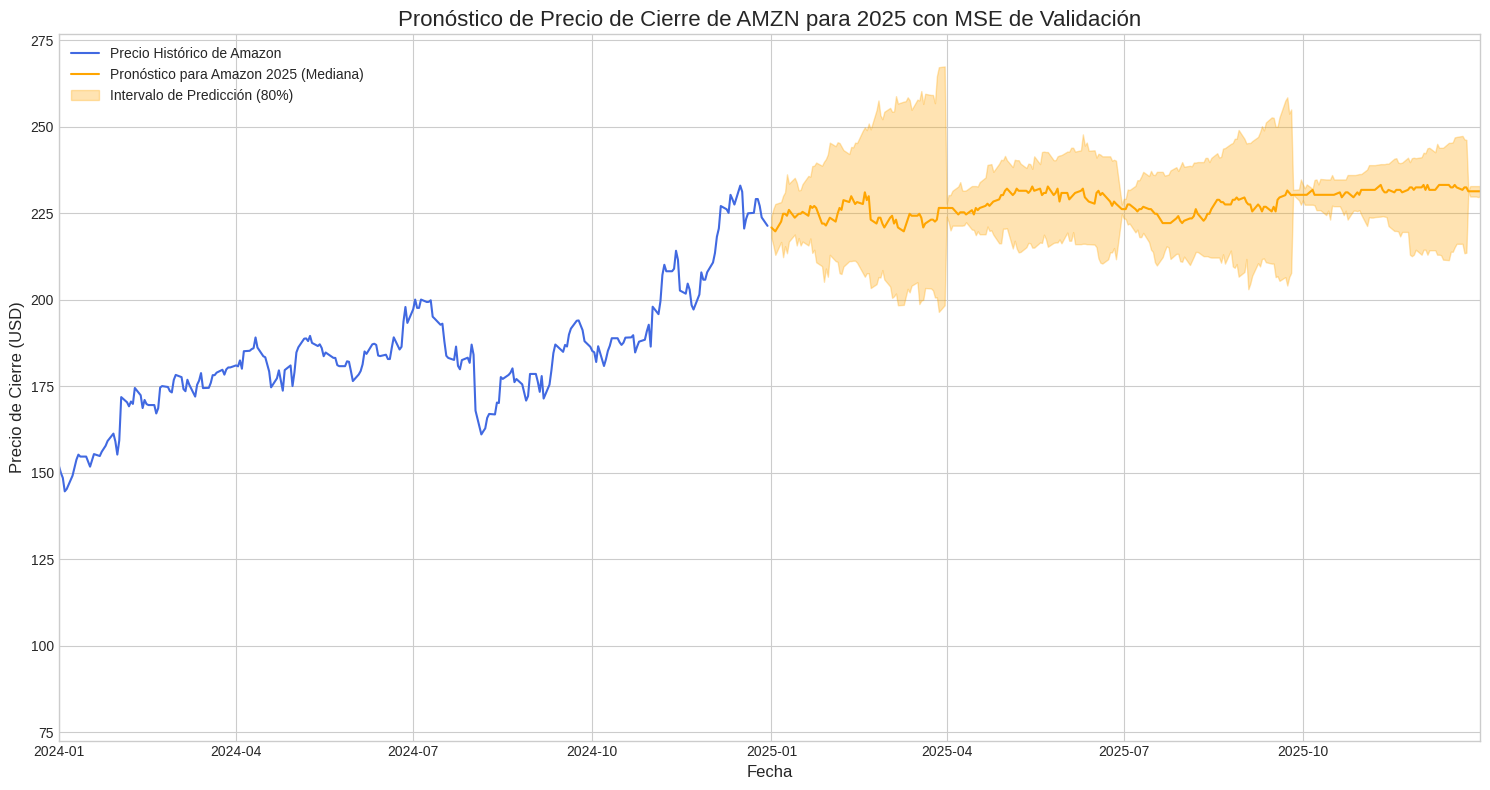

In [21]:
# Paso 1: Instalar las librerías necesarias
# Si no las has instalado, descomenta y ejecuta estas líneas en tu entorno
# !pip install torch
# !pip install chronos-forecasting
# !pip install accelerate
# !pip install scikit-learn

import pandas as pd
import torch
from chronos import BaseChronosPipeline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
import warnings

# --- Configuración ---
# Ignorar advertencias comunes para una salida más limpia
warnings.filterwarnings("ignore")

try:
    # --- 1. Cargar y Preparar los Datos ---
    print("Cargando el dataset 'dataset_completo_google_amazon.csv'...")
    df = pd.read_csv('dataset_completo_google_amazon.csv')

    # Convertir la columna 'Date' a formato datetime y establecerla como índice
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    # <<-- MODIFICACIÓN AQUÍ: Seleccionar la serie de tiempo de Amazon
    amazon_series = df['AMZN_Close'].asfreq('B').ffill()

    print(f"Datos históricos de Amazon cargados. La serie contiene {len(amazon_series)} puntos de datos de días hábiles.")
    print(f"El rango de fechas va de {amazon_series.index.min().date()} a {amazon_series.index.max().date()}.")

    # --- 2. Configurar el Pipeline de Chronos ---
    print("\nInicializando el pipeline de Amazon Chronos...")
    print("Este paso puede tardar un poco mientras se descarga el modelo.")

    device = "cuda" if torch.cuda.is_available() else "cpu"

    pipeline = BaseChronosPipeline.from_pretrained(
        "amazon/chronos-t5-small",
        device_map=device,
        torch_dtype=torch.bfloat16,
    )
    print(f"Pipeline cargado y funcionando en '{device}'.")

    # --- 3. Validación del Modelo y Cálculo del MSE ---
    print("\n--- Iniciando la fase de validación para calcular el error ---")

    validation_days = 66  # Aprox. 3 meses de días hábiles

    # Dividir los datos de Amazon
    train_data = amazon_series[:-validation_days]
    validation_data = amazon_series[-validation_days:]

    print(f"Usando datos hasta {train_data.index.max().date()} para entrenar.")
    print(f"Validando el pronóstico para el período de {validation_data.index.min().date()} a {validation_data.index.max().date()}.")

    # Preparar el contexto para el modelo
    validation_context = torch.tensor(train_data.values, dtype=torch.bfloat16)

    # Generar el pronóstico para el período de validación
    quantiles_tensor, _ = pipeline.predict_quantiles(
        context=validation_context.to(device),
        prediction_length=validation_days,
        quantile_levels=[0.5], # Solo necesitamos la mediana
    )

    median_forecast = quantiles_tensor.cpu().numpy()[0, :, 0]

    # Calcular el Error Cuadrático Medio (MSE)
    mse = mean_squared_error(validation_data.values, median_forecast)

    print("\n--- Resultados de la Validación ---")
    print(f"Error Cuadrático Medio (MSE) del pronóstico de Amazon: {mse:.4f}")

    # --- 4. Generar Pronóstico Final para 2025 ---
    print("\n--- Iniciando el pronóstico final para 2025 (usando todos los datos históricos) ---")

    # El contexto es la serie histórica completa de Amazon
    full_context = torch.tensor(amazon_series.values, dtype=torch.bfloat16)

    dias_habiles_2025 = pd.bdate_range(start='2025-01-01', end='2025-12-31')
    prediction_length = len(dias_habiles_2025)

    print(f"Realizando pronóstico para los {prediction_length} días hábiles de 2025...")

    # Predecir los cuantiles para 2025
    quantiles_tensor_2025, _ = pipeline.predict_quantiles(
        context=full_context.to(device),
        prediction_length=prediction_length,
        quantile_levels=[0.1, 0.5, 0.9],
    )

    quantiles_2025 = quantiles_tensor_2025.cpu().numpy()
    print("Pronóstico completado.")

    # --- 5. Procesar y Mostrar los Resultados de 2025 ---
    low, median, high = quantiles_2025[0, :, 0], quantiles_2025[0, :, 1], quantiles_2025[0, :, 2]

    forecast_df = pd.DataFrame(
        data={'Baja (10%)': low, 'Mediana (50%)': median, 'Alta (90%)': high},
        index=dias_habiles_2025
    )

    print("\n--- Primeros 10 días del pronóstico para AMZN en 2025 ---")
    print(forecast_df.head(10).to_string(float_format="%.2f"))
    print("\n--- Últimos 10 días del pronóstico para AMZN en 2025 ---")
    print(forecast_df.tail(10).to_string(float_format="%.2f"))

    # --- 6. Visualizar el Pronóstico Final ---
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(15, 8))

    ax.plot(amazon_series.index, amazon_series.values, color="royalblue", label="Precio Histórico de Amazon")
    ax.plot(forecast_df.index, forecast_df['Mediana (50%)'], color="orange", label="Pronóstico para Amazon 2025 (Mediana)")
    ax.fill_between(forecast_df.index,
                    forecast_df['Baja (10%)'],
                    forecast_df['Alta (90%)'],
                    color="orange", alpha=0.3, label="Intervalo de Predicción (80%)")

    ax.set_title('Pronóstico de Precio de Cierre de AMZN para 2025 con MSE de Validación', fontsize=16)
    ax.set_xlabel("Fecha", fontsize=12)
    ax.set_ylabel("Precio de Cierre (USD)", fontsize=12)
    ax.legend()
    ax.grid(True)

    ax.set_xlim([pd.to_datetime('2024-01-01'), pd.to_datetime('2025-12-31')])

    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\nHa ocurrido un error inesperado: {e}")
    print("Asegúrate de tener las librerías 'torch', 'chronos-forecasting' y 'accelerate' instaladas.")
    print("Si el error es de memoria (Out of Memory), puede que tu GPU o RAM no sea suficiente para esta operación.")

Cargando el dataset 'dataset_completo_google_amazon.csv'...
Datos históricos para Google y Amazon cargados y preparados.

Inicializando el pipeline de Amazon Chronos (esto puede tardar)...


Pipeline cargado y funcionando en 'cpu'.

Generando pronóstico para Google...


Pronóstico para Google completado.
Generando pronóstico para Amazon...
Pronóstico para Amazon completado.

Generando gráfico combinado...


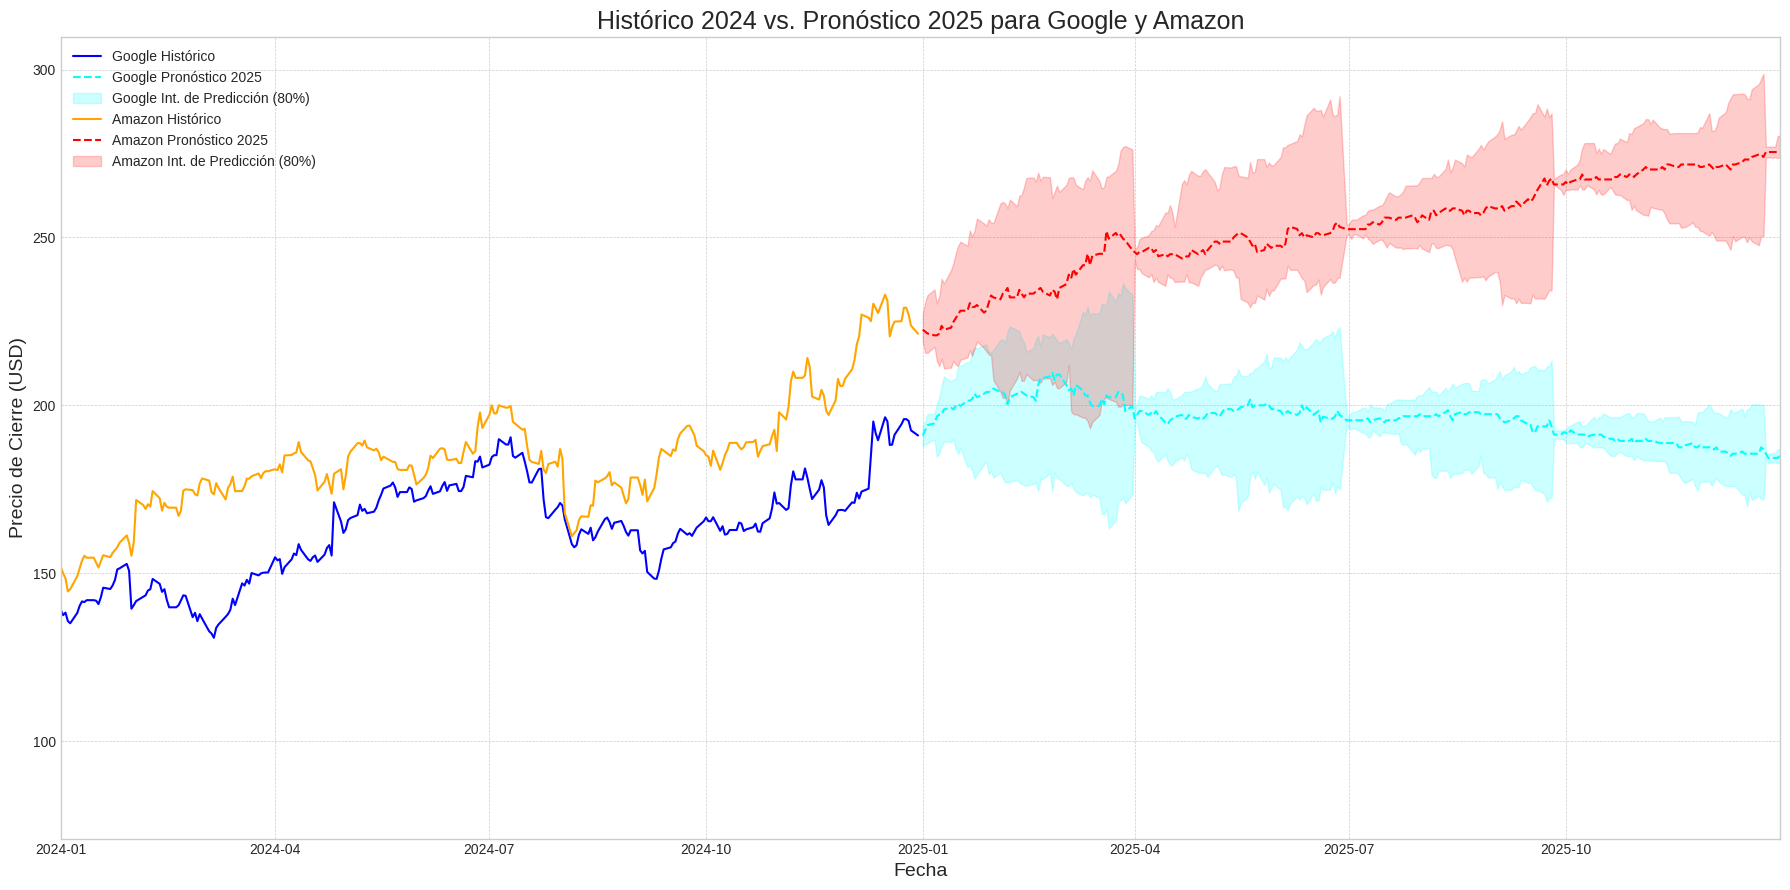

In [22]:
# Paso 1: Instalar las librerías necesarias
# Si no las has instalado, descomenta y ejecuta estas líneas en tu entorno.
# !pip install torch
# !pip install chronos-forecasting
# !pip install accelerate
# !pip install scikit-learn

import pandas as pd
import torch
from chronos import BaseChronosPipeline
import matplotlib.pyplot as plt
import warnings

# --- Configuración ---
warnings.filterwarnings("ignore")

try:
    # --- 1. Cargar y Preparar los Datos ---
    print("Cargando el dataset 'dataset_completo_google_amazon.csv'...")
    df = pd.read_csv('dataset_completo_google_amazon.csv')

    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

    # Preparar series para GOOGL y AMZN con frecuencia de días hábiles
    google_series = df['GOOGL_Close'].asfreq('B').ffill()
    amazon_series = df['AMZN_Close'].asfreq('B').ffill()

    print("Datos históricos para Google y Amazon cargados y preparados.")

    # --- 2. Configurar el Pipeline de Chronos ---
    print("\nInicializando el pipeline de Amazon Chronos (esto puede tardar)...")
    device = "cuda" if torch.cuda.is_available() else "cpu"

    pipeline = BaseChronosPipeline.from_pretrained(
        "amazon/chronos-t5-small",
        device_map=device,
        torch_dtype=torch.bfloat16,
    )
    print(f"Pipeline cargado y funcionando en '{device}'.")

    # --- 3. Generar Pronóstico para 2025 para GOOGLE ---
    print("\nGenerando pronóstico para Google...")
    context_googl = torch.tensor(google_series.values, dtype=torch.bfloat16)

    dias_habiles_2025 = pd.bdate_range(start='2025-01-01', end='2025-12-31')
    prediction_length = len(dias_habiles_2025)

    quantiles_googl_tensor, _ = pipeline.predict_quantiles(
        context=context_googl.to(device),
        prediction_length=prediction_length,
        quantile_levels=[0.1, 0.5, 0.9],
    )
    quantiles_googl = quantiles_googl_tensor.cpu().numpy()

    low_g, median_g, high_g = quantiles_googl[0, :, 0], quantiles_googl[0, :, 1], quantiles_googl[0, :, 2]
    forecast_df_googl = pd.DataFrame(
        data={'Baja': low_g, 'Mediana': median_g, 'Alta': high_g},
        index=dias_habiles_2025
    )
    print("Pronóstico para Google completado.")

    # --- 4. Generar Pronóstico para 2025 para AMAZON ---
    print("Generando pronóstico para Amazon...")
    context_amzn = torch.tensor(amazon_series.values, dtype=torch.bfloat16)

    quantiles_amzn_tensor, _ = pipeline.predict_quantiles(
        context=context_amzn.to(device),
        prediction_length=prediction_length,
        quantile_levels=[0.1, 0.5, 0.9],
    )
    quantiles_amzn = quantiles_amzn_tensor.cpu().numpy()

    low_a, median_a, high_a = quantiles_amzn[0, :, 0], quantiles_amzn[0, :, 1], quantiles_amzn[0, :, 2]
    forecast_df_amzn = pd.DataFrame(
        data={'Baja': low_a, 'Mediana': median_a, 'Alta': high_a},
        index=dias_habiles_2025
    )
    print("Pronóstico para Amazon completado.")

    # --- 5. Visualizar los Resultados Combinados ---
    print("\nGenerando gráfico combinado...")
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(18, 9))

    # Graficar datos históricos
    ax.plot(google_series.index, google_series.values, color="blue", label="Google Histórico")
    ax.plot(amazon_series.index, amazon_series.values, color="orange", label="Amazon Histórico")

    # Graficar pronósticos (mediana)
    ax.plot(forecast_df_googl.index, forecast_df_googl['Mediana'], color="cyan", linestyle='--', label="Google Pronóstico 2025")
    ax.plot(forecast_df_amzn.index, forecast_df_amzn['Mediana'], color="red", linestyle='--', label="Amazon Pronóstico 2025")

    # Rellenar intervalos de confianza
    ax.fill_between(forecast_df_googl.index,
                    forecast_df_googl['Baja'],
                    forecast_df_googl['Alta'],
                    color="cyan", alpha=0.2, label="Google Int. de Predicción (80%)")

    ax.fill_between(forecast_df_amzn.index,
                    forecast_df_amzn['Baja'],
                    forecast_df_amzn['Alta'],
                    color="red", alpha=0.2, label="Amazon Int. de Predicción (80%)")

    # Configuración del gráfico
    ax.set_title('Histórico 2024 vs. Pronóstico 2025 para Google y Amazon', fontsize=18)
    ax.set_xlabel("Fecha", fontsize=14)
    ax.set_ylabel("Precio de Cierre (USD)", fontsize=14)

    # Establecer los límites del eje X desde 2024 hasta 2025
    ax.set_xlim([pd.to_datetime('2024-01-01'), pd.to_datetime('2025-12-31')])

    # Organizar la leyenda para que no se superponga
    handles, labels = ax.get_legend_handles_labels()
    order = [0, 2, 4, 1, 3, 5]  # Orden para agrupar por compañía
    ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order], loc='upper left')

    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\nHa ocurrido un error inesperado: {e}")
    print("Asegúrate de tener las librerías 'torch', 'chronos-forecasting' y 'accelerate' instaladas.")

In [23]:
# Leer el dataset
import pandas as pd

df = pd.read_csv("dataset_completo_google_amazon.csv")

# Mostrar las primeras filas del dataset
df.head()
df

,Date,GOOGL_Close,AMZN_Close,Treasury_10Y,VIX,SP500,NASDAQ,GOOGL_Return_1d,AMZN_Return_1d,GOOGL_Volatility_20,AMZN_Volatility_20,Inflacion_T5YIE
0,2021-01-04,85.895844,159.331497,0.917,26.969999,3700.649902,12698.450195,0.008064,0.010004,3.410646,3.841592,1.98
1,2021-01-05,86.588524,160.925507,0.955,25.340000,3726.860107,12818.959961,0.008064,0.010004,3.410646,3.841592,2.01
2,2021-01-06,85.734100,156.919006,1.042,25.070000,3748.139893,12740.790039,-0.009868,-0.024897,3.410646,3.841592,2.04
3,2021-01-07,88.294868,158.108002,1.071,22.370001,3803.790039,13067.480469,0.029869,0.007577,3.410646,3.841592,2.09
4,2021-01-08,89.463783,159.134995,1.105,21.559999,3824.679932,13201.980469,0.013239,0.006496,3.410646,3.841592,2.07
...,...,...,...,...,...,...,...,...,...,...,...,...
992,2024-12-23,194.406113,225.059998,4.599,16.780001,5974.069824,19764.880859,0.016823,0.000622,10.948753,9.393671,2.38
993,2024-12-24,195.884399,229.050003,4.591,14.270000,6040.040039,20031.130859,0.007604,0.017729,10.885822,8.437937,2.39
994,2024-12-26,195.375000,227.050003,4.579,14.730000,6037.589844,20020.359375,-0.002601,-0.008732,10.709326,7.838409,2.39
995,2024-12-27,192.538254,223.750000,4.619,15.950000,5970.839844,19722.029297,-0.014519,-0.014534,10.235210,6.736610,2.38


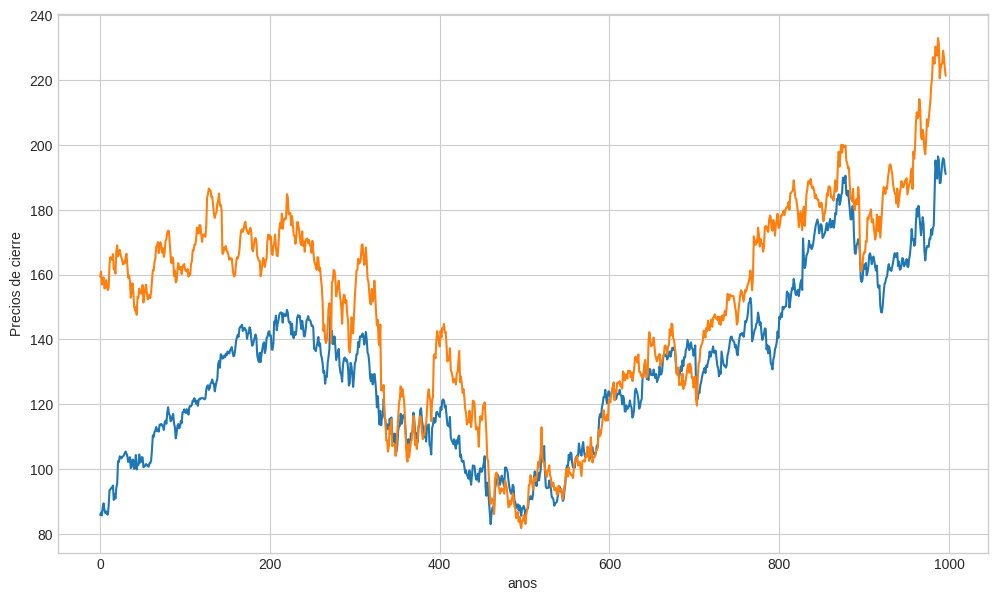

In [24]:
# Graficar el dataset
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 7))
df['GOOGL_Close'].plot(ax=ax);
df['AMZN_Close'].plot(ax=ax);
ax.set_xlabel("anos")
ax.set_ylabel("Precios de cierre");

In [26]:
import torch
from chronos import BaseChronosPipeline

# Crear pipeline: carga el modelo y lo mueve al dispositivo (GPU o CPU) y
# define el tipo de dato para almacenar variables numéricas

pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",  # el nombre del modelo
    device_map="cpu",  # CPU
    torch_dtype=torch.bfloat16,
)

In [29]:
# Predicción básica
# Tomar todo el dataset como entrada exceptuando el último año
N = 365
contexto = torch.tensor(df["GOOGL_Close"][:-N].values, dtype=torch.float)

# Generar la predicción con "predict"
pred1 = pipeline.predict(
    context=contexto, # La serie de entrada
    prediction_length=N, # Número de instantes de tiempo a predecir
)
print(pred1.shape)

torch.Size([1, 20, 365])


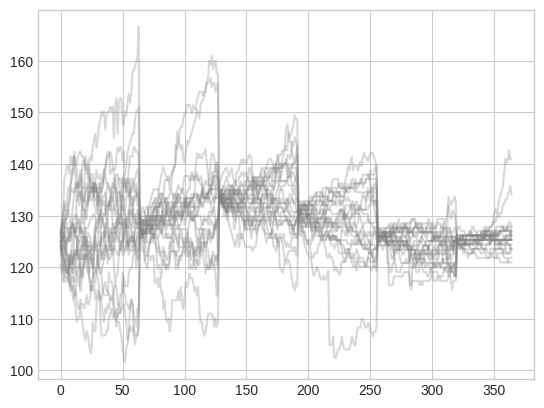

In [31]:
for i in range(20):
    plt.plot(pred1[0, i], color="gray", alpha=0.3)

In [32]:
# Calcular predicción promedio
pred1_mean = pred1.mean(dim=1)
print(pred1_mean.shape)

torch.Size([1, 365])


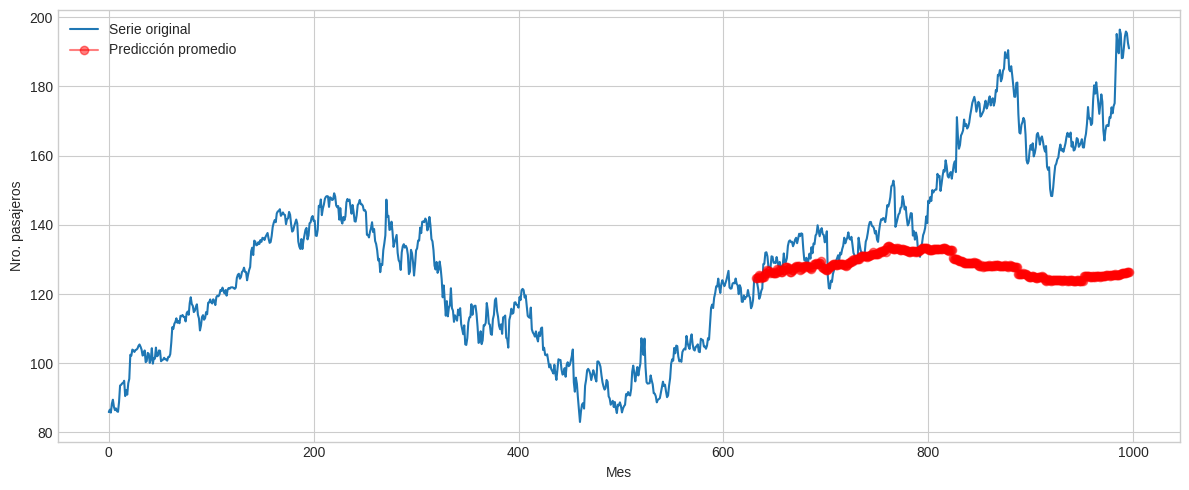

In [34]:
# Graficar dataset original y predicción
plt.figure(figsize=(12, 5))

# Original series
plt.plot(df["GOOGL_Close"].values, label="Serie original")

# Predicción
start_idx = len(contexto)
forecast_idx = range(start_idx, start_idx + N)
plt.plot(forecast_idx, pred1_mean.squeeze(), label="Predicción promedio", color="red", marker="o", alpha=0.5)

plt.xlabel("Mes")
plt.ylabel("Nro. pasajeros")
plt.legend()
plt.grid(True)
plt.tight_layout();

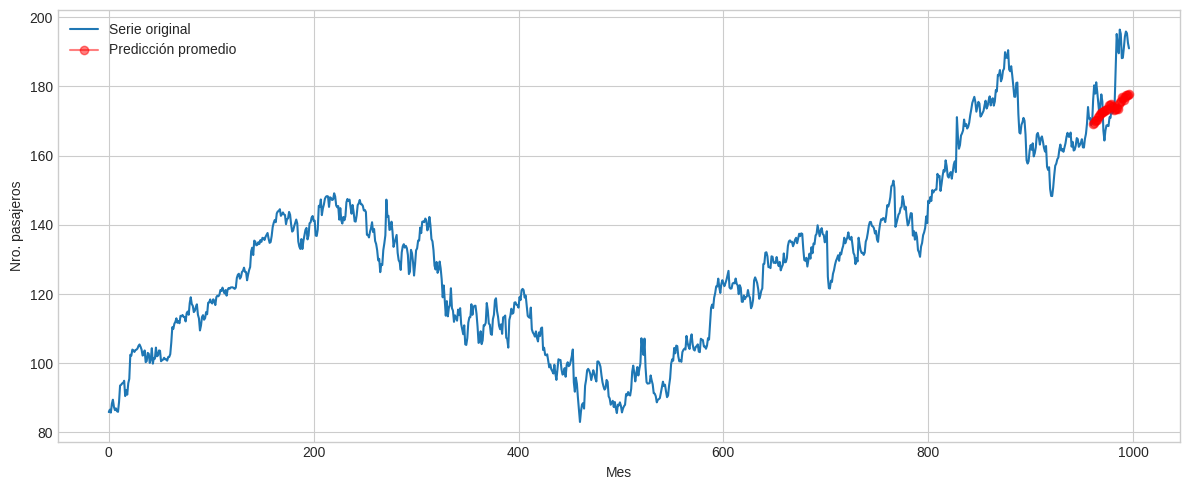

In [36]:
# Veamos una predicción a 3 años

# Contexto
N = 36
contexto = torch.tensor(df["GOOGL_Close"][:-N].values, dtype=torch.float)

# Predicción
pred1 = pipeline.predict(
    context=contexto,
    prediction_length=N,
)

# Calcular predicción promedio
pred1_mean = pred1.mean(dim=1)

# Gráfico serie original y predicción
plt.figure(figsize=(12, 5))

plt.plot(df["GOOGL_Close"].values, label="Serie original")

start_idx = len(contexto)
forecast_idx = range(start_idx, start_idx + N)
plt.plot(forecast_idx, pred1_mean.squeeze(), label="Predicción promedio", color="red", marker="o", alpha=0.5)

plt.xlabel("Mes")
plt.ylabel("Nro. pasajeros")
plt.legend()
plt.grid(True)
plt.tight_layout();

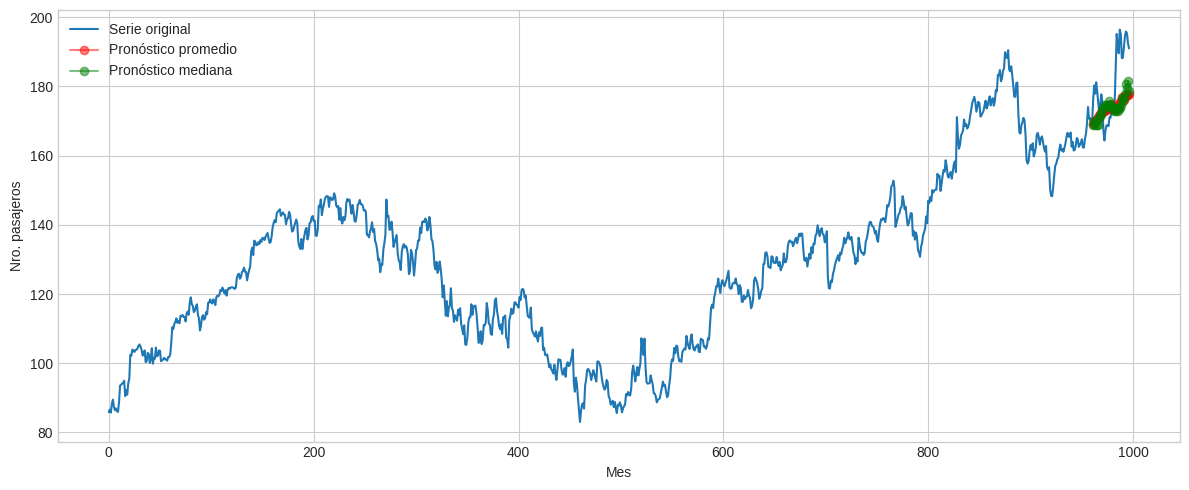

In [38]:
# calcular predicción con base en la mediana y comparar
pred1_median = pred1.median(dim=1).values

# Gráfico original y predicción
plt.figure(figsize=(12, 5))

# Serie original
plt.plot(df["GOOGL_Close"].values, label="Serie original")

# Pronóstico
start_idx = len(contexto)
forecast_idx = range(start_idx, start_idx + N)
plt.plot(forecast_idx, pred1_mean.squeeze(), label="Pronóstico promedio", color="red", marker="o", alpha=0.5)
plt.plot(forecast_idx, pred1_median.squeeze(), label="Pronóstico mediana", color="green", marker="o", alpha=0.5)

plt.xlabel("Mes")
plt.ylabel("Nro. pasajeros")
plt.legend()
plt.grid(True)
plt.tight_layout();

In [39]:
cuantiles, mean = pipeline.predict_quantiles(
    context=contexto,
    prediction_length=N,
    quantile_levels=[0.1, 0.5, 0.9], # Calcular cuantiles 10%, 50% (mediana) y 90%
)

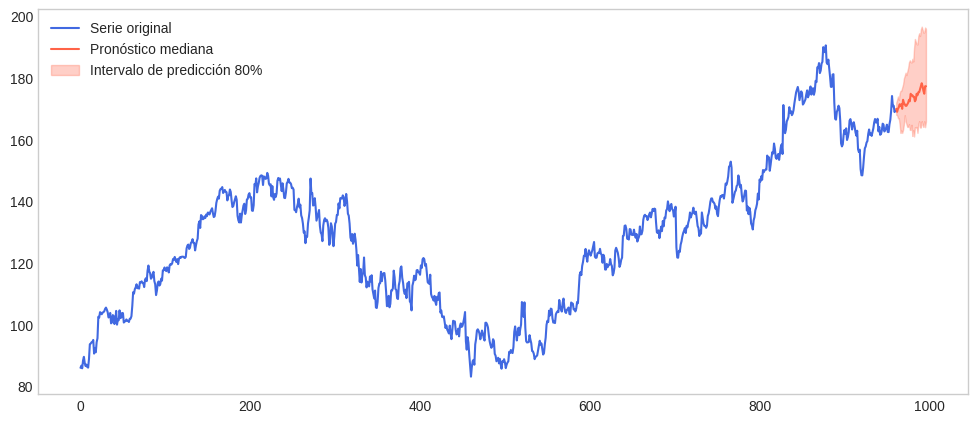

In [40]:
# Y graficar
import matplotlib.pyplot as plt

low, median, high = cuantiles[0, :, 0], cuantiles[0, :, 1], cuantiles[0, :, 2]

plt.figure(figsize=(12, 5))
start_idx = len(contexto)
forecast_idx = range(start_idx, start_idx + N)
plt.plot(contexto, color="royalblue", label="Serie original")
plt.plot(forecast_idx, median, color="tomato", label="Pronóstico mediana")
plt.fill_between(forecast_idx, low, high, color="tomato", alpha=0.3, label="Intervalo de predicción 80%")
plt.legend()
plt.grid();

In [41]:
# Crear un DataFrame con los pronósticos
forecast_data = {
    'Bajo (10%)': low,
    'Mediana (50%)': median,
    'Alto (90%)': high
}

# Generar las fechas para el índice del pronóstico
forecast_dates = pd.bdate_range(start=df.index[start_idx], periods=N, freq='B')

forecast_table = pd.DataFrame(forecast_data, index=forecast_dates)

# Mostrar la tabla de pronósticos
print("\n--- Tabla de Pronósticos (Primeros 10 días) ---")
display(forecast_table.head(10))

print("\n--- Tabla de Pronósticos (Últimos 10 días) ---")
display(forecast_table.tail(10))


--- Tabla de Pronósticos (Primeros 10 días) ---


,Bajo (10%),Mediana (50%),Alto (90%)
1970-01-01,167.954376,169.907333,171.957932
1970-01-02,167.856720,168.930847,172.836761
1970-01-05,166.880249,169.907333,173.910904
1970-01-06,166.880249,170.395569,172.836761
1970-01-07,164.732010,171.372040,174.887390
1970-01-08,162.095505,170.883804,175.766220
1970-01-09,162.876694,171.372040,175.766220
1970-01-12,162.095505,169.907333,176.840347
1970-01-13,163.071991,172.836777,177.816818
1970-01-14,164.927292,171.860291,179.769775



--- Tabla de Pronósticos (Últimos 10 días) ---


,Bajo (10%),Mediana (50%),Alto (90%)
1970-02-06,164.927292,175.277969,193.538132
1970-02-09,165.903778,175.277969,194.416962
1970-02-10,163.853165,176.254456,193.538132
1970-02-11,163.853165,177.230927,195.686386
1970-02-12,165.903778,178.207413,196.565201
1970-02-13,164.829651,177.230927,195.588730
1970-02-16,164.048462,175.766205,194.612259
1970-02-17,165.903778,174.789734,194.709915
1970-02-18,163.950821,177.230927,196.272263
1970-02-19,165.806122,177.230927,195.784027


In [43]:
# --- Generar Pronóstico para 2025 (usando todos los datos históricos) ---
print("Iniciando el pronóstico para 2025 (usando todos los datos históricos)...")

# El contexto es la serie histórica completa de Google
full_context_googl = torch.tensor(google_series.values, dtype=torch.bfloat16)

# Definir los días hábiles de 2025 para la predicción
dias_habiles_2025 = pd.bdate_range(start='2025-01-01', end='2025-12-31')
prediction_length_2025 = len(dias_habiles_2025)

print(f"Realizando pronóstico para los {prediction_length_2025} días hábiles de 2025...")

# Predecir los cuantiles para 2025
quantiles_googl_2025_tensor, _ = pipeline.predict_quantiles(
    context=full_context_googl.to(device), # Use the 'device' variable
    prediction_length=prediction_length_2025,
    quantile_levels=[0.1, 0.5, 0.9],
)

quantiles_googl_2025 = quantiles_googl_2025_tensor.cpu().numpy()
print("Pronóstico para 2025 completado.")

# --- Procesar y Mostrar los Resultados de 2025 en una Tabla ---
low_2025, median_2025, high_2025 = quantiles_googl_2025[0, :, 0], quantiles_googl_2025[0, :, 1], quantiles_googl_2025[0, :, 2]

forecast_df_2025 = pd.DataFrame(
    data={'Bajo (10%)': low_2025, 'Mediana (50%)': median_2025, 'Alta (90%)': high_2025},
    index=dias_habiles_2025
)

print("\n--- Tabla de Pronósticos para GOOGL en 2025 (Primeros 10 días) ---")
display(forecast_df_2025.head(10))

print("\n--- Tabla de Pronósticos para GOOGL en 2025 (Últimos 10 días) ---")
display(forecast_df_2025.tail(10))

Iniciando el pronóstico para 2025 (usando todos los datos históricos)...
Realizando pronóstico para los 261 días hábiles de 2025...
Pronóstico para 2025 completado.

--- Tabla de Pronósticos para GOOGL en 2025 (Primeros 10 días) ---


,Bajo (10%),Mediana (50%),Alta (90%)
2025-01-01,189.848633,190.990433,194.104401
2025-01-02,188.914444,193.066406,195.246201
2025-01-03,188.499252,194.104401,198.256363
2025-01-06,188.603043,195.142395,199.398163
2025-01-07,185.696671,195.142395,199.709564
2025-01-08,186.215668,196.699371,202.200729
2025-01-09,186.215668,197.737366,204.691910
2025-01-10,181.752304,197.218369,203.550140
2025-01-13,180.714310,195.661377,202.719742
2025-01-14,176.354736,196.699371,206.664108



--- Tabla de Pronósticos para GOOGL en 2025 (Últimos 10 días) ---


,Bajo (10%),Mediana (50%),Alta (90%)
2025-12-18,175.001282,194.165695,225.812195
2025-12-19,173.866547,194.165695,224.803543
2025-12-22,170.210190,196.687317,226.190445
2025-12-23,168.949371,198.578552,225.938278
2025-12-24,172.605728,197.317719,224.425293
2025-12-25,193.727036,195.044907,196.362778
2025-12-26,194.913116,195.044907,197.680649
2025-12-29,194.913116,196.362778,197.680649
2025-12-30,193.727036,196.362778,197.680649
2025-12-31,194.913116,196.362778,197.680649
